# Feature Extraction

## Time-Frequency Features

### Import the required modules

In [381]:
import tensorflow as tf
from reader import AudioReader
from preprocessing import Normalization, Padding

### Specify the input file path

In [382]:
filename = 'msc-train/down_b9515bf3_nohash_0.wav'

### Read the WAV file & Apply preprocessing

In [383]:
audio_reader = AudioReader(tf.int16)
padding = Padding(16000)
normalization = Normalization(tf.int16)

audio, label = audio_reader.get_audio_and_label(filename)
audio, label = padding.pad(audio, label)
audio, label = normalization.normalize(audio, label)

### Compute the Spectrogram

In [384]:
frame_length_in_s = 0.008
frame_step_in_s = 0.002
num_mel_bins = 32
lower_frequency = 50
upper_frequency = 5000
num_coefficients = 10
sampling_rate = 16000

frame_length = int(frame_length_in_s * sampling_rate)
frame_step = int(frame_step_in_s * sampling_rate)

print('Frame Length:', frame_length)
print('Frame Step:', frame_step)

stft = tf.signal.stft(
    audio, 
    frame_length=frame_length,
    frame_step=frame_step,
    fft_length=frame_length
)
spectrogram = tf.abs(stft)

print('Spectrogram shape:', spectrogram.shape)
# (# Frames=(16000-640)/320+1, # Frequncy Bins=640/2+1)

Frame Length: 128
Frame Step: 32
Spectrogram shape: (497, 65)


### Plot the Spectrogram

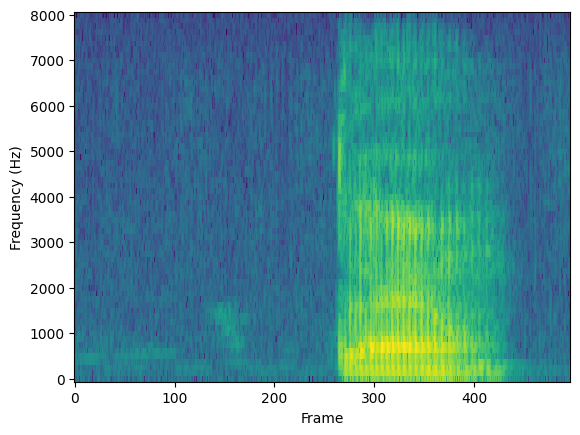

In [385]:
import matplotlib.pyplot as plt
import numpy as np

log_spectrogram = tf.math.log(spectrogram + 1.e-6)

# Matplotlib requires (Y, X) data for a correct visualization
log_spectrogram_vis = tf.transpose(log_spectrogram)


frames = np.arange(0, log_spectrogram.shape[0])
frequencies = np.linspace(0, sampling_rate // 2, log_spectrogram.shape[1])
plt.pcolormesh(frames, frequencies, log_spectrogram_vis.numpy())
plt.xlabel('Frame')
plt.ylabel('Frequency (Hz)')
plt.show()

### Create a class for Spectrogram

In [386]:
class Spectrogram():
    def __init__(self, sampling_rate, frame_length_in_s, frame_step_in_s):
        self.frame_length = int(frame_length_in_s * sampling_rate)
        self.frame_step = int(frame_step_in_s * sampling_rate)

    def get_spectrogram(self, audio):
        stft = tf.signal.stft(
            audio, 
            frame_length=self.frame_length,
            frame_step=self.frame_step,
            fft_length=self.frame_length
        )
        spectrogram = tf.abs(stft)

        return spectrogram

    def get_spectrogram_and_label(self, audio, label):
        spectrogram = self.get_spectrogram(audio)

        return spectrogram, label

### Test the Spectrogram Class

In [387]:
spec_processor = Spectrogram(16000, frame_length_in_s, frame_step_in_s)
spectrogram, label = spec_processor.get_spectrogram_and_label(audio, label)

print('Spectrogram:', spectrogram)
print('Label:', label)

Spectrogram: tf.Tensor(
[[3.1679877e-04 2.9513912e-04 3.9800562e-04 ... 2.6479562e-05
  2.0938191e-05 6.7137007e-06]
 [3.7296204e-04 6.7747390e-04 4.9316871e-04 ... 9.1483431e-05
  6.2954168e-05 4.1762250e-05]
 [2.1966838e-04 7.7454565e-04 1.1933694e-03 ... 9.5365205e-05
  7.4712865e-05 6.9953239e-07]
 ...
 [1.4065837e-03 1.0612364e-03 7.7981944e-04 ... 5.1329651e-05
  5.0454400e-05 4.3302480e-05]
 [6.1101082e-04 4.6144114e-04 7.0966396e-04 ... 3.9889830e-05
  4.0925006e-05 4.2502943e-06]
 [1.5810425e-03 2.1540995e-03 2.1191586e-03 ... 7.0772294e-05
  7.9333819e-05 9.8368619e-05]], shape=(497, 65), dtype=float32)
Label: tf.Tensor(b'down', shape=(), dtype=string)


### Compute the log-Mel Spectrogram

First, compute the Mel Filterbanks (also called Linear-to-Mel Weight Matrix).

In [388]:
num_spectrogram_bins = spectrogram.shape[1] # frame_length // 2 + 1

linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=num_mel_bins,
    num_spectrogram_bins=num_spectrogram_bins,
    sample_rate=sampling_rate,
    lower_edge_hertz=lower_frequency,
    upper_edge_hertz=upper_frequency
)
print('Mel Filters Matrix shape:', linear_to_mel_weight_matrix.shape)

Mel Filters Matrix shape: (65, 32)


Then, compute the Mel spectrogram with a simple matrix multiplication.

In [389]:
mel_spectrogram = tf.matmul(spectrogram, linear_to_mel_weight_matrix)

print('Mel Spectrogram shape:', mel_spectrogram.shape)

log_mel_spectrogram = tf.math.log(mel_spectrogram + 1.e-6)

Mel Spectrogram shape: (497, 32)


### Plot the log-Mel Spectrogram

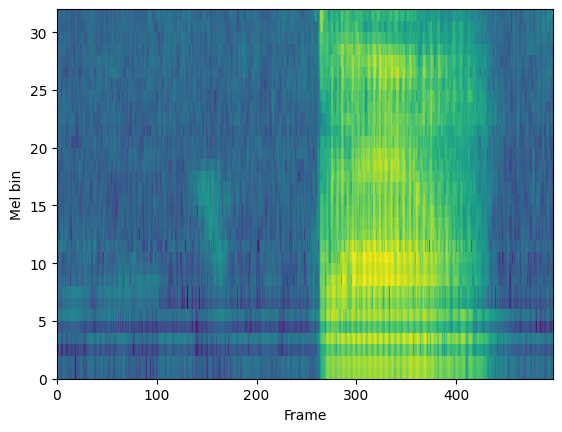

In [390]:
# Matplotlib requires (Y, X) data for a correct visualization
log_mel_spectrogram_vis = tf.transpose(log_mel_spectrogram)

plt.pcolormesh(log_mel_spectrogram_vis.numpy())
plt.xlabel('Frame')
plt.ylabel('Mel bin')
plt.show()

### Create a class for log-Mel Spectrogram

In [391]:
class MelSpectrogram():
    def __init__(
        self, 
        sampling_rate,
        frame_length_in_s,
        frame_step_in_s,
        num_mel_bins,
        lower_frequency,
        upper_frequency
    ):
        self.spectrogram_processor = Spectrogram(sampling_rate, frame_length_in_s, frame_step_in_s)
        num_spectrogram_bins = self.spectrogram_processor.frame_length // 2 + 1

        self.linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=num_mel_bins,
            num_spectrogram_bins=num_spectrogram_bins,
            sample_rate=sampling_rate,
            lower_edge_hertz=lower_frequency,
            upper_edge_hertz=upper_frequency
        )

    def get_mel_spec(self, audio):
        spectrogram = self.spectrogram_processor.get_spectrogram(audio)
        mel_spectrogram = tf.matmul(spectrogram, self.linear_to_mel_weight_matrix)
        log_mel_spectrogram = tf.math.log(mel_spectrogram + 1.e-6)

        return log_mel_spectrogram

    def get_mel_spec_and_label(self, audio, label):
        log_mel_spectrogram = self.get_mel_spec(audio)

        return log_mel_spectrogram, label

### Test the log-Mel Spectrogram Class

In [392]:
mel_spec_processor = MelSpectrogram(16000, frame_length_in_s, frame_step_in_s, num_mel_bins, lower_frequency, upper_frequency)
log_mel_spectrogram, label = mel_spec_processor.get_mel_spec_and_label(audio, label)

print('Log-Mel Spectrogram:', log_mel_spectrogram)
print('Label:', label)

Log-Mel Spectrogram: tf.Tensor(
[[-8.920821  -8.7183275 -9.685474  ... -7.93496   -7.5408616 -7.7808666]
 [-8.0941305 -7.8908596 -9.474197  ... -8.239761  -7.6183047 -7.8685904]
 [-7.960635  -7.757289  -8.598182  ... -8.055249  -8.25208   -7.926513 ]
 ...
 [-7.646497  -7.4430075 -9.020783  ... -7.2858634 -7.065258  -6.6147532]
 [-8.476615  -8.273625  -9.114237  ... -6.962853  -6.572175  -6.071362 ]
 [-6.939621  -6.735936  -8.026314  ... -6.9103217 -6.7733603 -6.319147 ]], shape=(497, 32), dtype=float32)
Label: tf.Tensor(b'down', shape=(), dtype=string)


### Compute the MFCCs

In [393]:
mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)
print('MFCCs shape:', mfccs.shape)

MFCCs shape: (497, 32)


### Plot the MFCCs

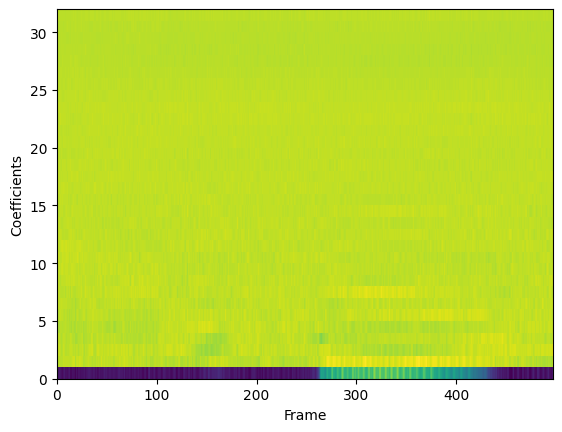

In [394]:
mfccs_vis = tf.transpose(mfccs)

plt.pcolormesh(mfccs_vis.numpy())
plt.xlabel('Frame')
plt.ylabel('Coefficients')
plt.show()

### Select the most important coefficients

In [395]:
mfccs = mfccs[..., :num_coefficients]

print('MFCCs shape:', mfccs.shape)

MFCCs shape: (497, 10)


### Create a class for MFCCs

In [396]:
class MFCC():
    def __init__(
        self, 
        sampling_rate,
        frame_length_in_s,
        frame_step_in_s,
        num_mel_bins,
        lower_frequency,
        upper_frequency,
        num_coefficients
    ):
        self.mel_spec_processor = MelSpectrogram(
            sampling_rate, frame_length_in_s, frame_step_in_s, num_mel_bins, lower_frequency, upper_frequency
        )
        self.num_coefficients = num_coefficients

    def get_mfccs(self, audio):
        log_mel_spectrogram = self.mel_spec_processor.get_mel_spec(audio)
        mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)
        mfccs = mfccs[..., :self.num_coefficients]

        return mfccs

    def get_mfccs_and_label(self, audio, label):
        mfccs = self.get_mfccs(audio)

        return mfccs, label

### Test the MFCC class

In [397]:
mfcc_processor = MFCC(16000, frame_length_in_s, frame_step_in_s, num_mel_bins, lower_frequency, upper_frequency, num_coefficients)
mfccs, label = mfcc_processor.get_mfccs_and_label(audio, label)

print('MFCCs:', mfccs)
print('Label:', label)

MFCCs: tf.Tensor(
[[-6.5913696e+01 -8.4470972e-02  2.9877353e-01 ... -9.3505156e-01
   1.1820601e+00  3.9518532e-01]
 [-6.4049126e+01 -5.2047938e-01  7.7343267e-01 ...  3.5564739e-01
   2.6576447e-01  3.5871655e-01]
 [-6.2380856e+01 -2.0168944e-01  1.2920080e+00 ... -2.4062930e-02
  -3.6670411e-01  5.2374214e-01]
 ...
 [-6.5424789e+01 -1.7573292e+00  2.0025010e+00 ...  1.2018422e+00
   8.9242965e-01 -5.9819859e-01]
 [-6.5989044e+01 -2.8315740e+00  1.8343786e+00 ... -2.1472460e-02
   1.4284494e+00 -8.9089923e-02]
 [-6.3665653e+01 -4.0086541e-01  3.7425981e+00 ... -5.2913517e-01
   5.1353604e-01 -1.6704520e-02]], shape=(497, 10), dtype=float32)
Label: tf.Tensor(b'down', shape=(), dtype=string)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b4ef5aa4-3f71-4837-91f1-c6fd9810a7ea' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>